In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [37]:
data = pd.read_csv("test.csv")
data.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,0
1,im updating my blog because i feel shitty,0
2,i never make her separate from me because i do...,0
3,i left with my bouquet of red and yellow tulip...,1
4,i was feeling a little vain when i did this one,0


In [38]:
data.label.unique()

array([0, 1, 4, 3, 2, 5])

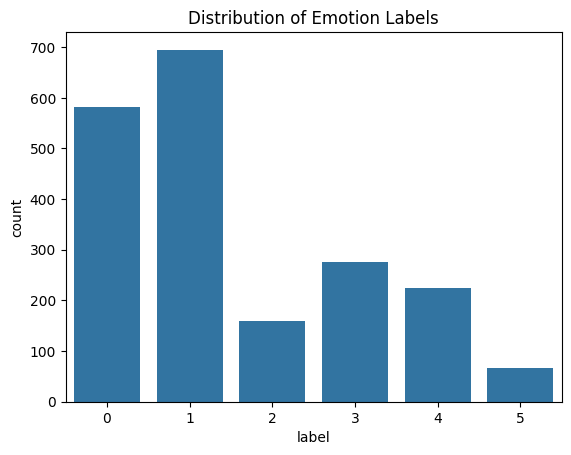

In [39]:
sns.countplot(x="label", data=data)
plt.title("Distribution of Emotion Labels")
plt.show()

In [40]:
label_map = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}

print(label_map)

{0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string

nltk.download("all")

In [42]:
stop_words = set(stopwords.words("english"))

negation_words = {
    "no",
    "not",
    "never",
    "none",
    "nobody",
    "nothing",
    "neither",
    "nowhere",
    "doesn't",
    "isn't",
    "wasn't",
    "shouldn't",
    "wouldn't",
    "couldn't",
    "won't",
    "can't",
    "don't",
    "didn't",
    "doesnt",
    "isnt",
    "wasnt",
    "shouldnt",
    "wouldnt",
    "couldnt",
    "wont",
    "cant",
    "dont",
    "didnt",
    "doesn",
    "isn",
    "wasn",
    "shouldn",
    "wouldn",
    "couldn",
    "will not",
    "can t",
    "don t",
    "didn t",
    "doesn t",
    "isn t",
    "wasn t",
    "shouldn t",
    "wouldn t",
    "couldn t",
}

custom_stop_words = stop_words - negation_words

lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    words = word_tokenize(text)
    words = [
        lemmatizer.lemmatize(word) for word in words if word not in custom_stop_words
    ]
    return " ".join(words)

In [43]:
data["cleaned_text"] = data["text"].apply(preprocess_text)

In [44]:
data.head()

,text,label,cleaned_text
0,im feeling rather rotten so im not very ambiti...,0,im feeling rather rotten im not ambitious right
1,im updating my blog because i feel shitty,0,im updating blog feel shitty
2,i never make her separate from me because i do...,0,never make separate ever want feel like ashamed
3,i left with my bouquet of red and yellow tulip...,1,left bouquet red yellow tulip arm feeling slig...
4,i was feeling a little vain when i did this one,0,feeling little vain one


In [45]:
from sklearn.model_selection import train_test_split

x = data["cleaned_text"]
y = data["label"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer

vector = TfidfVectorizer(
    max_features=5000
)  # 5000 most important words, ignore the rest

x_train = vector.fit_transform(x_train)

x_test = vector.transform(x_test)

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from sklearn.naive_bayes import MultinomialNB

In [48]:
nb_model = MultinomialNB()

nb_params = {
    "alpha": [0.1, 0.5, 1.0, 1.5, 2.0],
}

nb_grid = GridSearchCV(
    estimator=nb_model, param_grid=nb_params, cv=5, scoring="accuracy", n_jobs=-1
)
nb_grid.fit(x_train, y_train)

print("Best Parameters:", nb_grid.best_params_)
print("Best Score:", nb_grid.best_score_)

Best Parameters: {'alpha': 0.1}
Best Score: 0.65


In [49]:
model = MultinomialNB()
model.fit(x_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [50]:
y_pred = model.predict(x_test)

In [ ]:
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
lr_model = LogisticRegression(max_iter=1000)

lr_params = {
    "C": [0.01, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs", "saga"],
}

lr_grid = GridSearchCV(
    estimator=lr_model, param_grid=lr_params, cv=5, scoring="accuracy", n_jobs=-1
)
lr_grid.fit(x_train, y_train)

print("Best Parameters:", lr_grid.best_params_)
print("Best Score: ", lr_grid.best_score_)

In [ ]:
parameters = {"C": 10, "penalty": "l2", "solver": "saga"}
model = LogisticRegression(**parameters)
model.fit(x_train, y_train)

In [54]:
y_pred = model.predict(x_test)

In [55]:
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.84      0.81       124
           1       0.66      0.94      0.78       131
           2       0.73      0.23      0.35        35
           3       0.74      0.54      0.62        52
           4       0.74      0.53      0.62        43
           5       0.50      0.07      0.12        15

    accuracy                           0.72       400
   macro avg       0.69      0.52      0.55       400
weighted avg       0.72      0.72      0.69       400

Accuracy: 0.7175


In [56]:
from sklearn.svm import SVC

# Support Vector Machine (SVM) model
svm_model = SVC()

svm_params = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear"],
}

svm_grid = GridSearchCV(
    estimator=svm_model, param_grid=svm_params, cv=5, scoring="accuracy", n_jobs=-1
)
svm_grid.fit(x_train, y_train)

print("Best Parameters:", svm_grid.best_params_)
print("Best Score:", svm_grid.best_score_)

Best Parameters: {'C': 10, 'kernel': 'linear'}
Best Score: 0.691875


In [57]:
parameters = {"C": 1, "degree": 2, "gamma": "scale", "kernel": "linear"}

svc_model = SVC(**parameters)
svc_model.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",2
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [58]:
y_pred = svc_model.predict(x_test)

In [59]:
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.83      0.81       124
           1       0.63      0.98      0.76       131
           2       0.75      0.09      0.15        35
           3       0.79      0.42      0.55        52
           4       0.69      0.51      0.59        43
           5       1.00      0.13      0.24        15

    accuracy                           0.70       400
   macro avg       0.77      0.49      0.52       400
weighted avg       0.73      0.70      0.66       400

Accuracy: 0.7


In [60]:
import joblib

with open("vector.joblib", "wb") as model_file:
    joblib.dump(vector, model_file)

with open("svc_model.joblib", "wb") as model_file:
    joblib.dump(svc_model, model_file)